# NER/C

## Goal
We are tasked with analysing a file by using 2 different systems to extract NEs.
Error analysis should also be performed to explain differences in performances, and we'll also be making suggestions on how to improve the systems.

## Game Plan

Named entity recognition/classification is the process of identifying and classifying units of text. There are many methods of accomplishing this task but our approach is outlined as follows:
- **Data processing**:
    This is important because it helps mitigate the adage "garbage in, garbage out."
    - The data will be preprocessed i.e., cleaned (trimming white space, removing unknown characters/headers)
    - And then formatted (removing stopwords, lemmatising if appropriate, and tokenizing).
- **Feature representation**:
    This step converts the strings into numerical units, with which our algorithms have an easier time with.
    We'll be using *Word2Vec* to represent the data, because it retains context and relationships between tokens.
- **NER/C**:
    The 2 systems that will be compared are:
    - <u>Logistic Regression</u>: Which is a common base line model used in NLP.
    - fine-tuned <u>spaCy</u>: A framework for text analysis, fine-tuned on the data.
- **Results/Analysis**:
    Both systems will be tasked to predict the "goal" file, and then their performances will be logged, graphed and discussed.


## Data
We'll be using [multinerd](https://huggingface.co/datasets/Babelscape/multinerd), which taken directly from their summary:

<div class="alert alert-block alert-info">
"In a nutshell, MultiNERD is the first language-agnostic methodology for automatically creating multilingual, multi-genre and fine-grained annotations for Named Entity Recognition and Entity Disambiguation."
</div>

### Statistics of dataset

Load in the data.

In [ ]:
# %pip install pandas
import pandas as pd

train_file: str = "../../data/multinerd/train/train_en.jsonl"
test_file: str = "../../data/multinerd/test/test_en.jsonl"
train_data_frame: pd.DataFrame = pd.read_json(path_or_buf=train_file, lines=True)

Actual statistics.

In [72]:
tag_label_to_id = {
    "O": 0,
    "B-PER": 1,
    "I-PER": 2,
    "B-ORG": 3,
    "I-ORG": 4,
    "B-LOC": 5,
    "I-LOC": 6,
    "B-ANIM": 7,
    "I-ANIM": 8,
    "B-BIO": 9,
    "I-BIO": 10,
    "B-CEL": 11,
    "I-CEL": 12,
    "B-DIS": 13,
    "I-DIS": 14,
    "B-EVE": 15,
    "I-EVE": 16,
    "B-FOOD": 17,
    "I-FOOD": 18,
    "B-INST": 19,
    "I-INST": 20,
    "B-MEDIA": 21,
    "I-MEDIA": 22,
    "B-MYTH": 23,
    "I-MYTH": 24,
    "B-PLANT": 25,
    "I-PLANT": 26,
    "B-TIME": 27,
    "I-TIME": 28,
    "B-VEHI": 29,
    "I-VEHI": 30,
}

# Easier to see their labels rather than ID
tag_id_to_label = dict((v,k) for k,v in tag_label_to_id.items())

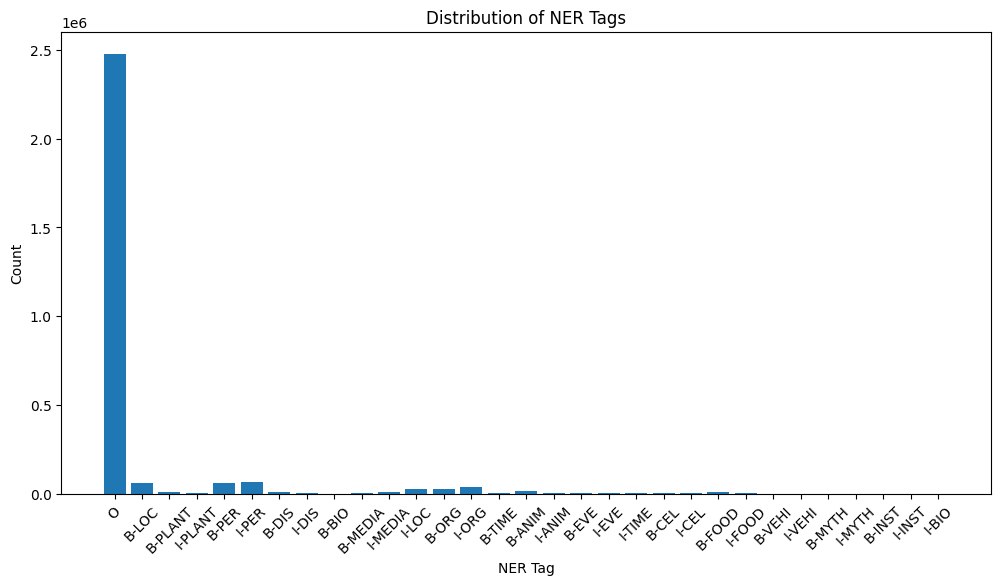

In [5]:
# %pip install jinja2
# %pip install matplotlib

from collections import Counter
import matplotlib.pyplot as plt

all_tag_labels = [tag_id_to_label.get(tag, "UNK") for tags in train_data_frame['ner_tags'] for tag in tags]

tag_label_counts = Counter(all_tag_labels)

plt.figure(figsize=(12, 6))
plt.bar(tag_label_counts.keys(), tag_label_counts.values())
plt.xlabel("NER Tag")
plt.ylabel("Count")
plt.title("Distribution of NER Tags")
plt.xticks(rotation=45)
plt.show()

In [6]:
train_tag_counts = pd.DataFrame(tag_label_counts.items(), columns=['Tag', 'Count'])
train_tag_counts = train_tag_counts.sort_values(by='Count', ascending=False).reset_index(drop=True)
print(train_tag_counts)

        Tag    Count
0         O  2478599
1     I-PER    66188
2     B-PER    62987
3     B-LOC    58665
4     I-ORG    35999
5     B-ORG    27641
6     I-LOC    24400
7    B-ANIM    12736
8   I-MEDIA    10035
9     B-DIS     8702
10   B-FOOD     8279
11  B-PLANT     7436
12  B-MEDIA     6081
13    I-DIS     5804
14   I-ANIM     5307
15    I-EVE     4203
16   I-FOOD     3030
17    B-CEL     2685
18   B-TIME     2540
19    B-EVE     2525
20  I-PLANT     2351
21   I-TIME     1971
22    I-CEL     1486
23   B-MYTH      569
24   I-VEHI      478
25   B-VEHI      404
26   B-INST      379
27   I-INST      363
28    B-BIO      140
29   I-MYTH      101
30    I-BIO       35


The most occuring tag is $O$ which is to be expected since most words are not entities. There's also a lot of instances, proving the claims we made above.

*Side note: It would have been nice to have a more balanced data set, but languages usually aren't laid out that way. Certain type of words are expected to appear more than others.*

### Processing

The data is luckily already formatted and cleaned, it's up to us now to convert it to numerical features.
As mentioned in the outline we'll be using *word2vec* as our method of feature representation.

### Feature representation

Taken from the Word2Vec documentation:

- vector_size: Dimensionality of the word vectors.
    - We'll set this to $300$

- window: Maximum distance between the current and predicted word within a sentence.
    - We'll set this to $10$

- min_count: Ignores all words with total frequency lower than this.
    - We'll start with $1$

- workers: Use these many worker threads to train the model (=faster training with multicore machines).
    - Change depending on machine, I'll set it to $4$

In [7]:
# Required to remain compatible with gensim
# %pip install numpy==1.23.5
# %pip install gensim==4.3.3

from gensim.models import Word2Vec

# Train Word2Vec on tokens
sentences = train_data_frame['tokens'].tolist()

w2v_params = {
    "vector_size": 300,
    "window": 10,
    "min_count": 1,
    "workers": 4,
}

w2v_model = Word2Vec(sentences, **w2v_params)

An example feature representation.

In [8]:
print(w2v_model.wv["Named"])

[-3.00174877e-02 -5.27491160e-02 -4.60701901e-03  5.85329570e-02
 -3.00948378e-02 -2.66766902e-02  3.36258709e-02  5.06202728e-02
 -1.30323146e-03 -1.81449112e-02  8.52084626e-03 -1.29456818e-02
  1.87763087e-02 -2.14712247e-02  1.95917068e-03 -6.26049750e-03
  1.16088362e-02  3.63652501e-03  3.46543603e-02  1.56406686e-02
 -3.43413204e-02  2.33660359e-02  1.95886064e-02  3.75083387e-02
  2.29929294e-02 -1.56221744e-02 -6.01279102e-02  3.19429114e-02
 -2.28676852e-02 -1.27989445e-02  5.32699749e-02 -1.06061837e-02
  6.64128363e-02  5.07681407e-02 -1.16903214e-02  2.94694155e-02
  2.35329475e-02 -8.00781995e-02 -3.78897786e-02  4.62841131e-02
 -5.60343452e-02 -2.73993127e-02  6.04193658e-04 -9.46944021e-03
 -2.60039233e-02  1.76928169e-03 -2.81645544e-02  2.59208735e-02
 -8.55640788e-03  5.15792333e-02  4.37877998e-02  5.55559359e-02
 -6.51587965e-03 -3.12887388e-03  1.89493445e-03  7.73414550e-03
  1.45856971e-02  2.76104286e-02  3.79784480e-02  7.07947556e-03
  1.21801244e-02  3.31924

A helper function to convert the tokens to embeddings.

In [9]:
import numpy as np

def get_embedding(token):
    if token in w2v_model.wv:
        return w2v_model.wv[token]
    else:
        return np.zeros(w2v_model.vector_size)

### To pipeline

Let's set the input and targets for both systems.

#### For Log-Reg

In [89]:
X = []
for tokens_list in train_data_frame['tokens']:
    for token in tokens_list:
        X.append(get_embedding(token))

y = []
for tags_list in train_data_frame['ner_tags']:
    for tag in tags_list:
        y.append(tag)

And finally create the train/test split.

In [11]:
# %pip install scikit-learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### For spaCy

We'll be fine-tuning spaCy (roberta-base) on the GPU, but to we'll also be evaluating locally.

We need to reformat the data for local evaluation. This helper function does that.

In [ ]:
def bio_to_spacy_format(tokens, tags):
    text = " ".join(tokens)
    entities = []

    start = None
    end = None
    current_label = None

    char_idx = 0
    for i, (token, tag) in enumerate(zip(tokens, tags)):
        token_len = len(token)
        space = 1 if i < len(tokens) - 1 else 0

        if tag.startswith("B-"):
            if current_label is not None and current_label != "O":
                entities.append((start, end, current_label))
            current_label = tag[2:]
            start = char_idx
            end = char_idx + token_len
        elif tag.startswith("I-") and current_label == tag[2:]:
            end = char_idx + token_len
        else:
            if current_label is not None and current_label != "O":
                entities.append((start, end, current_label))
                current_label = None

        char_idx += token_len + space

    if current_label is not None and current_label != "O":
        entities.append((start, end, current_label))

    return text, {"entities": entities}

Create a new test set that's been properly formatted.

In [13]:
test_spacy_data = []
for tokens, tag_ids in zip(train_data_frame['tokens'], train_data_frame['ner_tags']):
    bio_tags = [tag_id_to_label.get(tag, "O") for tag in tag_ids]
    text, annotations = bio_to_spacy_format(tokens, bio_tags)
    test_spacy_data.append((text, annotations))

*Side note: Minor optimisation can be made by introducing NLP here for creating <u>Example</u>s.*

### End of chapter
As a final note on the data chapter, here's the laTex for citing multinerd:
<div class="alert alert-block alert-info">
@inproceedings{tedeschi-navigli-2022-multinerd,
    title = "{M}ulti{NERD}: A Multilingual, Multi-Genre and Fine-Grained Dataset for Named Entity Recognition (and Disambiguation)",
    author = "Tedeschi, Simone  and
      Navigli, Roberto",
    booktitle = "Findings of the Association for Computational Linguistics: NAACL 2022",
    month = jul,
    year = "2022",
    address = "Seattle, United States",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2022.findings-naacl.60",
    doi = "10.18653/v1/2022.findings-naacl.60",
    pages = "801--812",
    abstract = "Named Entity Recognition (NER) is the task of identifying named entities in texts and classifying them through specific semantic categories, a process which is crucial for a wide range of NLP applications. Current datasets for NER focus mainly on coarse-grained entity types, tend to consider a single textual genre and to cover a narrow set of languages, thus limiting the general applicability of NER systems.In this work, we design a new methodology for automatically producing NER annotations, and address the aforementioned limitations by introducing a novel dataset that covers 10 languages, 15 NER categories and 2 textual genres.We also introduce a manually-annotated test set, and extensively evaluate the quality of our novel dataset on both this new test set and standard benchmarks for NER.In addition, in our dataset, we include: i) disambiguation information to enable the development of multilingual entity linking systems, and ii) image URLs to encourage the creation of multimodal systems.We release our dataset at https://github.com/Babelscape/multinerd.",
}
</div>

## Systems

Implementations of both systems.

### Logistic Regression (LR)

Set up the model.

In [52]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()

Start training.

In [53]:
lr_clf.fit(X_train, y_train)

c:\Users\jalen\OneDrive\Documents\School\BSc AI\Y2\TM\ba-text-mining\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Predict the test set.

In [54]:
lr_pred = lr_clf.predict(X_test)

Performance/Results.

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.95    495819
           1       0.77      0.49      0.60     12576
           2       0.55      0.14      0.22     13052
           3       0.52      0.13      0.21      5548
           4       0.60      0.26      0.37      7170
           5       0.71      0.52      0.60     11660
           6       0.76      0.38      0.51      4891
           7       0.82      0.07      0.13      2587
           8       0.16      0.01      0.02      1056
           9       0.00      0.00      0.00        31
          10       0.00      0.00      0.00         6
          11       0.62      0.16      0.26       546
          12       0.00      0.00      0.00       306
          13       0.28      0.01      0.03      1763
          14       0.48      0.17      0.26      1139
          15       0.56      0.19      0.28       483
          16       0.78      0.48      0.59       788
          17       0.14    

c:\Users\jalen\OneDrive\Documents\School\BSc AI\Y2\TM\ba-text-mining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jalen\OneDrive\Documents\School\BSc AI\Y2\TM\ba-text-mining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jalen\OneDrive\Documents\School\BSc AI\Y2\TM\ba-text-mining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division`

### spaCy

Set up spaCy.

In [ ]:
# %pip install spacy
# !python -m spacy download en_core_web_md
import spacy

nlp = spacy.load("en_core_web_md")

c:\Users\jalen\OneDrive\Documents\School\BSc AI\Y2\TM\ba-text-mining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Use the word2vec embeddings.

In [15]:
for word in w2v_model.wv.key_to_index:
    nlp.vocab.set_vector(word, w2v_model.wv[word])

Ensure NER is enabled.

In [16]:
if "ner" not in nlp.pipe_names:
    ner = nlp.add_pipe("ner", last=True)
else:
    ner = nlp.get_pipe("ner")

Add the (new) labels to the NER pipeline.

In [17]:
entity_labels = set()
for _, annotations in test_spacy_data:
    for ent in annotations.get("entities"):
        entity_labels.add(ent[2])

print("Labels added to NER:", entity_labels)
for label in entity_labels:
    ner.add_label(label)

Labels added to NER: {'TIME', 'ANIM', 'VEHI', 'FOOD', 'MEDIA', 'INST', 'LOC', 'PER', 'CEL', 'DIS', 'MYTH', 'ORG', 'PLANT', 'EVE', 'BIO'}


#### Training

In order to save on compute (time) we'll be training with a smaller sample size first.

In [19]:
import random

input_file = train_file
reduced_output_file = "./data/train_sample_10k.jsonl"
sample_size = 10000

with open(input_file, "r", encoding="utf8") as f:
    lines = f.readlines()

sampled_lines = random.sample(lines, sample_size)

# Write sample to new file
with open(reduced_output_file, "w", encoding="utf8") as f_out:
    for line in sampled_lines:
        f_out.write(line)

Next we'll convert the data (file) to $.spacy$ format.

In [20]:
train_file_spacy = reduced_output_file
test_file_spacy = test_file

Helper function for conversion.

In [21]:
def iob_to_spans(tags):
    spans = []
    start = None
    label = None
    for i, tag in enumerate(tags):
        tag = tag_id_to_label.get(tag, "UNK")
        if tag.startswith("B-"):
            if start is not None:
                spans.append((start, i, label))
            start = i
            label = tag[2:]
        elif tag.startswith("I-") and start is not None and tag[2:] == label:
            continue
        else:
            if start is not None:
                spans.append((start, i, label))
                start = None
                label = None
    if start is not None:
        spans.append((start, len(tags), label))
    return spans

Conversion function.

In [22]:
from spacy.tokens import Doc, DocBin
import json

def to_spacy(in_file, out_file):
    doc_bin = DocBin()
    with open(in_file, "r", encoding="utf8") as f:
        for line in f:
            data = json.loads(line)
            tokens = data["tokens"]
            tags = data["ner_tags"]

            # Build spacing logic
            spaces = []
            for i, token in enumerate(tokens):
                # Insert space if the next token isn't punctuation or attached
                if i < len(tokens) - 1 and not tokens[i+1].startswith("'") and not token in [".", ",", ":", ";", "!", "?"]:
                    spaces.append(True)
                else:
                    spaces.append(False)

            # Create the Doc object
            doc = Doc(nlp.vocab, words=tokens, spaces=spaces)

            # Convert token-level IOB to character spans
            spans = iob_to_spans(tags)
            ents = []
            for start_idx, end_idx, label in spans:
                start_char = doc[start_idx].idx
                end_char = doc[end_idx - 1].idx + len(doc[end_idx - 1])
                span = doc.char_span(start_char, end_char, label=label)
                if span is not None:
                    ents.append(span)
                else:
                    print(f"⚠️ Skipping misaligned span: {doc[start_idx:end_idx].text} ({label})")
            doc.ents = ents
            doc_bin.add(doc)

    doc_bin.to_disk(f"./data/{out_file}.spacy")


Actual conversion.

In [23]:
to_spacy(train_file_spacy, "train")
to_spacy(test_file_spacy, "test")

The model is trained online, so we're skipping it here.\
Uncomment the following lines to train.

In [24]:
# %pip install -U spacy[transformers]
# !python -m spacy init fill-config /content/base_config.cfg config.cfg
# !nvidia-smi ---> To get gpu id, then proceed
## !python -m spacy train /content/config.cfg --gpu-id 0 --output ./output

Load in the trained model.

In [ ]:
model_path = "../../data/model-best/"
nlp = spacy.load(model_path)

#### Evaluation

Convert test data to $Example$ s. *This could have been done in the data chapter, but I didn't want to include any nlp imports there.*

In [ ]:
from spacy.training import Example

examples = []
for data in test_spacy_data:
    doc = nlp.make_doc(data[0])
    examples.append(Example.from_dict(doc, data[1]))

Evalution on multinerd.

In [38]:
score = nlp.evaluate(random.sample(examples, 1000))

In [39]:
import pprint
pprint.pp(score)

{'token_acc': 1.0,
 'token_p': 1.0,
 'token_r': 1.0,
 'token_f': 1.0,
 'ents_p': 0.9251302083333334,
 'ents_r': 0.9132390745501285,
 'ents_f': 0.9191461836998707,
 'ents_per_type': {'LOC': {'p': 0.997867803837953,
                           'r': 0.9957446808510638,
                           'f': 0.9968051118210862},
                   'FOOD': {'p': 0.6266666666666667,
                            'r': 0.5340909090909091,
                            'f': 0.5766871165644173},
                   'PER': {'p': 0.9979296066252588,
                           'r': 0.9938144329896907,
                           'f': 0.9958677685950412},
                   'DIS': {'p': 0.7065217391304348,
                           'r': 0.7738095238095238,
                           'f': 0.7386363636363635},
                   'ORG': {'p': 0.979381443298969,
                           'r': 0.9844559585492227,
                           'f': 0.9819121447028423},
                   'ANIM': {'p': 0.7282608695652174

Evalution on goal.

## Models Side by Side

In [ ]:
goal_file = "../../data/goal/NER-test.tsv"

### LR

In [62]:
def load_bio_dataframe(file_path: str):
    df = pd.read_csv(file_path, sep="\t")
    return df

In [91]:
goal_df = load_bio_dataframe(goal_file)

tokens = goal_df["token"].tolist()
tags = goal_df["BIO_NER_tag"].tolist()

goal_tokens = []
for token in tokens:
    goal_tokens.append(get_embedding(token))

goal_actual = []
for tag in tags:
    goal_actual.append(tag_label_to_id.get(tag, 0))

assert len(goal_tokens) == len(goal_actual)

In [81]:
lr_goal_pred = lr_clf.predict(goal_tokens)

### spaCy

In [ ]:
def load_bio_ner_file(file_path: str, nlp):
    df = pd.read_csv(file_path, sep="\t")

    examples = []

    for _, group in df.groupby("sentence_id"):
        tokens = group["token"].tolist()
        tags = group["BIO_NER_tag"].tolist()

        doc = Doc(nlp.vocab, words=tokens)
        formatted = bio_to_spacy_format(tokens, tags)

        doc = nlp.make_doc(formatted[0])
        example = Example.from_dict(doc, formatted[1])
        examples.append(example)

    return examples

In [ ]:
goal_examples = load_bio_ner_file(goal_file, nlp)

In [ ]:
goal_scores = nlp.evaluate(goal_examples)

### Side-by-Side

Logistic Regression's (LR) performance.

In [92]:
print(classification_report(goal_actual, lr_goal_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       203
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.50      0.12      0.20         8
           4       0.67      0.40      0.50         5
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0

    accuracy                           0.88       216
   macro avg       0.30      0.21      0.23       216
weighted avg       0.94      0.88      0.90       216



c:\Users\jalen\OneDrive\Documents\School\BSc AI\Y2\TM\ba-text-mining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jalen\OneDrive\Documents\School\BSc AI\Y2\TM\ba-text-mining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jalen\OneDrive\Documents\School\BSc AI\Y2\TM\ba-text-mining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control th

spaCy's performance.

In [ ]:
pprint.pp(goal_scores)

{'token_acc': 1.0,
 'token_p': 1.0,
 'token_r': 1.0,
 'token_f': 1.0,
 'ents_p': 0.9251302083333334,
 'ents_r': 0.9132390745501285,
 'ents_f': 0.9191461836998707,
 'ents_per_type': {'LOC': {'p': 0.997867803837953,
                           'r': 0.9957446808510638,
                           'f': 0.9968051118210862},
                   'FOOD': {'p': 0.6266666666666667,
                            'r': 0.5340909090909091,
                            'f': 0.5766871165644173},
                   'PER': {'p': 0.9979296066252588,
                           'r': 0.9938144329896907,
                           'f': 0.9958677685950412},
                   'DIS': {'p': 0.7065217391304348,
                           'r': 0.7738095238095238,
                           'f': 0.7386363636363635},
                   'ORG': {'p': 0.979381443298969,
                           'r': 0.9844559585492227,
                           'f': 0.9819121447028423},
                   'ANIM': {'p': 0.7282608695652174

## Discussion

<div align="center">
  <table>
    <tr>
      <th></th>
      <th>precision</th>
      <th>recall</th>
      <th>f1-score</th>
      <th>support</th>
    </tr>
    <tr>
      <td><strong>LR - macro avg</strong></td>
      <td>0.30</td>
      <td>0.21</td>
      <td>0.23</td>
      <td>216</td>
    </tr>
    <tr>
      <td><strong>LR - weighted avg</strong></td>
      <td>0.94</td>
      <td>0.88</td>
      <td>0.90</td>
      <td>216</td>
    </tr>
    <tr>
      <td><strong>SC - ents</strong></td>
      <td>0.92</td>
      <td>0.91</td>
      <td>0.92</td>
      <td>10000</td>
    </tr>
  </table>
</div>

The reason the macro avg of the LR is so low is because of class imbalance, as seen in the data chapter. Ignoring the imbalance we see that its weighted performance is relatively good. Our fine-tuned spaCy model performed well given the new data. The LR performs better in precision compared to spaCy, but recall and f1 are better done with spaCy.

## Conclusion and Limitations

Both systems performed well over the multinerd dataset. The LR model was much simpler and faster to compute than fine-tuning spaCy, which without the use of a GPU would have taken weeks to tune. However spaCy did perform better in recall and f1 than the LR, so if we're looking at the general score achieved across all measurements than the added complexity was beneficial.
Given more time we would have liked to train on the full multinerd set, we believe that our fine-tuning had minimal impact due to the small size. It also would have been interesting to use the word2vec embeddings as vectors during the GPU training, but it was another layer of complexity which time did not permit.